In [121]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [7]:

device = torch.device("mps")

In [8]:
device

device(type='mps')

In [10]:
# Функция апркосимации
def aproximation(x, y):
    return torch.sin(x + 2*y) * torch.exp(-(2*x + y)**2)

In [11]:
N = 20000
x = (torch.rand(N, 1) * 20 - 10) # Срез по условию [-10;10]
y = (torch.rand(N, 1) * 20 - 10) # Срез по условию [-10;10]
z = aproximation(x, y) # Цель модели

In [12]:
data = torch.cat([x, y, z], dim=1) # Объединяем x, y, z в одном массиве
idx = torch.randperm(N) # Перемешиваем данные
data = data[idx]

In [13]:
train_end = int(0.7 * N) # 70% данных для обучения
val_end = int(0.85 * N) # 85% данных для валидации

In [14]:
train = data[:train_end]
val = data[train_end:val_end]
test = data[val_end:]

In [15]:
X_train, y_train = train[:, :2], train[:, 2:]
X_val, y_val = val[:, :2], val[:, 2:]
X_test, y_test = test[:, :2], test[:, 2:]

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),      # Полносвязный слой
            nn.ReLU(),              # Функция активации
            nn.BatchNorm1d(256),    # Нормализация батчей
            nn.Linear(256, 128),    # Еще один полносвязный слой
            nn.ReLU(),              # Функция активации
            nn.BatchNorm1d(128),    # Нормализация
            nn.Linear(128, 64),     # Третий полносвязный слой
            nn.ReLU(),              # Функция активации
            nn.Linear(64, 1)        # Выходной слой
        )
    def forward(self, x):
        return self.model(x)

In [43]:
model = Net().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,  # оптимизатор, у которого меняем learning rate
    patience=50,  # ждем 50 эпох без улучшений
    factor=0.5    # уменьшаем learning rate в 2 раза
    )
"""
learning rate (скорость обучения). <br>
слишком большой → модель "скачет" <br>
слишком маленький → учится очень медленно <br>
👉 0.001 — стандартное значение для Adam
"""

'\nlearning rate (скорость обучения). <br>\nслишком большой → модель "скачет" <br>\nслишком маленький → учится очень медленно <br>\n👉 0.001 — стандартное значение для Adam\n'

In [36]:
model

Net(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [39]:
epochs = 500
train_losses = []
val_losses = []

In [ ]:
for epoch in range(epochs):
    # Train
    model.train()
    pred = model(X_train)
    loss = criterion(pred, y_train)
    """
    Градиентный спуск - спуск с горы:
    1. zero_grad()  - смотрим, где сейчас стоим
    2. backward()   - определяем, куда склон (градиент)
    3. step()       - делаем шаг вниз по склону
    """
    optimizer.zero_grad() # ОБНУЛЕНИЕ ГРАДИЕНТОВ
    # Зачем? Градиенты накапливаются (суммируются) по умолчанию
    # Без обнуления: grad_new = grad_old + grad_current
    # Нам нужно: grad_new = grad_current
    loss.backward() # ВЫЧИСЛЕНИЕ ГРАДИЕНТОВ
    # Считает частные производные: ∂loss/∂weight для каждого веса
    # Показывает, в какую сторону нужно менять каждый вес
    optimizer.step() # ОБНОВЛЕНИЕ ВЕСОВ
    
    train_losses.append(loss.item())
    
    # Validation
    model.eval()
    with torch.no_grad():
        # Весь код внутри не отслеживает градиенты
        """
        Что делает:
        Отключает построение графа вычислений
        Не сохраняет промежуточные значения для backward()
        Экономит память (в 2-3 раза)
        Ускоряет вычисления (на 20-30%)

        Когда использовать:
        Во время валидации/тестирования (не нужно обучать)
        Когда нужны только предсказания, без обучения
        """
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)
        val_losses.append(val_loss.item())
    
    scheduler.step(val_loss) # Проверяет, улучшился ли val_loss за последние patience эпох
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}')

Epoch [100/500], Train Loss: 0.013747, Val Loss: 0.016963
Epoch [200/500], Train Loss: 0.008931, Val Loss: 0.011898
Epoch [300/500], Train Loss: 0.004421, Val Loss: 0.007404
Epoch [400/500], Train Loss: 0.003434, Val Loss: 0.004040
Epoch [500/500], Train Loss: 0.001248, Val Loss: 0.001895


In [ ]:
model.eval() # Переводим модель в режим оценки
with torch.no_grad(): # Отключаем градиенты
    test_pred = model(X_test)
    mse = criterion(test_pred, y_test)

| | model.eval() | torch.no_grad() |
|---|-------------|-----------------|
| **Суть** | "Правильность" | "Эффективность" |
| **Без него** | ❌ Неправильные ответы | 🐌 Медленно и много памяти |
| **Когда нужен** | Всегда на тесте | Всегда на тесте |

In [46]:
print(f"\n{'='*50}")
print(f"ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:")
print(f"{'='*50}")
print(f"MSE на тестовой выборке: {mse.item():.6f}")
print(f"RMSE: {np.sqrt(mse.item()):.6f}")
print(f"{'='*50}\n")


ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:
MSE на тестовой выборке: 0.002650
RMSE: 0.051482



In [122]:
def graph_learning(axes, train_losses, val_losses):
    axes.plot(train_losses, label='Train Loss', alpha=0.7)
    axes.plot(val_losses, label='Val Loss', alpha=0.7)
    axes.set_xlabel('Epoch')
    axes.set_ylabel('MSE Loss')
    axes.set_title('Training and Validation Loss')
    axes.legend()
    axes.grid(True)
    axes.set_yscale('log')


In [123]:
def true_vs_pred(axes, true_np, pred_np):
    axes.scatter(true_np, pred_np, alpha=0.3, s=1)
    min_val = min(true_np.min(), pred_np.min())
    max_val = max(true_np.max(), pred_np.max())
    axes.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (y=x)', linewidth=2)
    axes.set_xlabel('True Values')
    axes.set_ylabel('Predicted Values')
    axes.set_title(f'True vs Predicted (MSE: {mse.item():.6f})')
    axes.legend()
    axes.grid(True)

In [124]:
def diagramm_errors(axes, errors):
    axes.hist(errors, bins=50, edgecolor='black', alpha=0.7)
    axes.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero error')
    axes.set_xlabel('Prediction Error')
    axes.set_ylabel('Frequency')
    axes.set_title(f'Error Distribution (std: {errors.std():.6f})')
    axes.legend()
    axes.grid(True)

In [125]:
def true_vs_errors(axes, true_np, errors):
    axes.scatter(true_np, errors, alpha=0.3, s=1)
    axes.axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes.set_xlabel('True Values')
    axes.set_ylabel('Prediction Error')
    axes.set_title('Error vs True Value')
    axes.grid(True)

In [131]:
true_np = y_test.cpu().numpy()
pred_np = test_pred.cpu().numpy()
errors = pred_np - true_np
def view_result_from_all_visual():
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0, 0].text(0.5, 0.5, "СССР", transform=axes[0, 0].transAxes, ha='center', fontsize=20, color='red')
    axes[0, 1].text(0.5, 0.5, "СССР", transform=axes[0, 1].transAxes, ha='center', fontsize=20, color='red')
    axes[1, 0].text(0.5, 0.5, "СССР", transform=axes[1, 0].transAxes, ha='center', fontsize=20, color='red')
    axes[1, 1].text(0.5, 0.5, "СССР", transform=axes[1, 1].transAxes, ha='center', fontsize=20, color='red')
    graph_learning(axes[0, 0], train_losses, val_losses)
    true_vs_pred(axes[0, 1], true_np, pred_np)
    diagramm_errors(axes[1, 0], errors)
    true_vs_errors(axes[1, 1], true_np, errors)

    plt.tight_layout()
    plt.show()


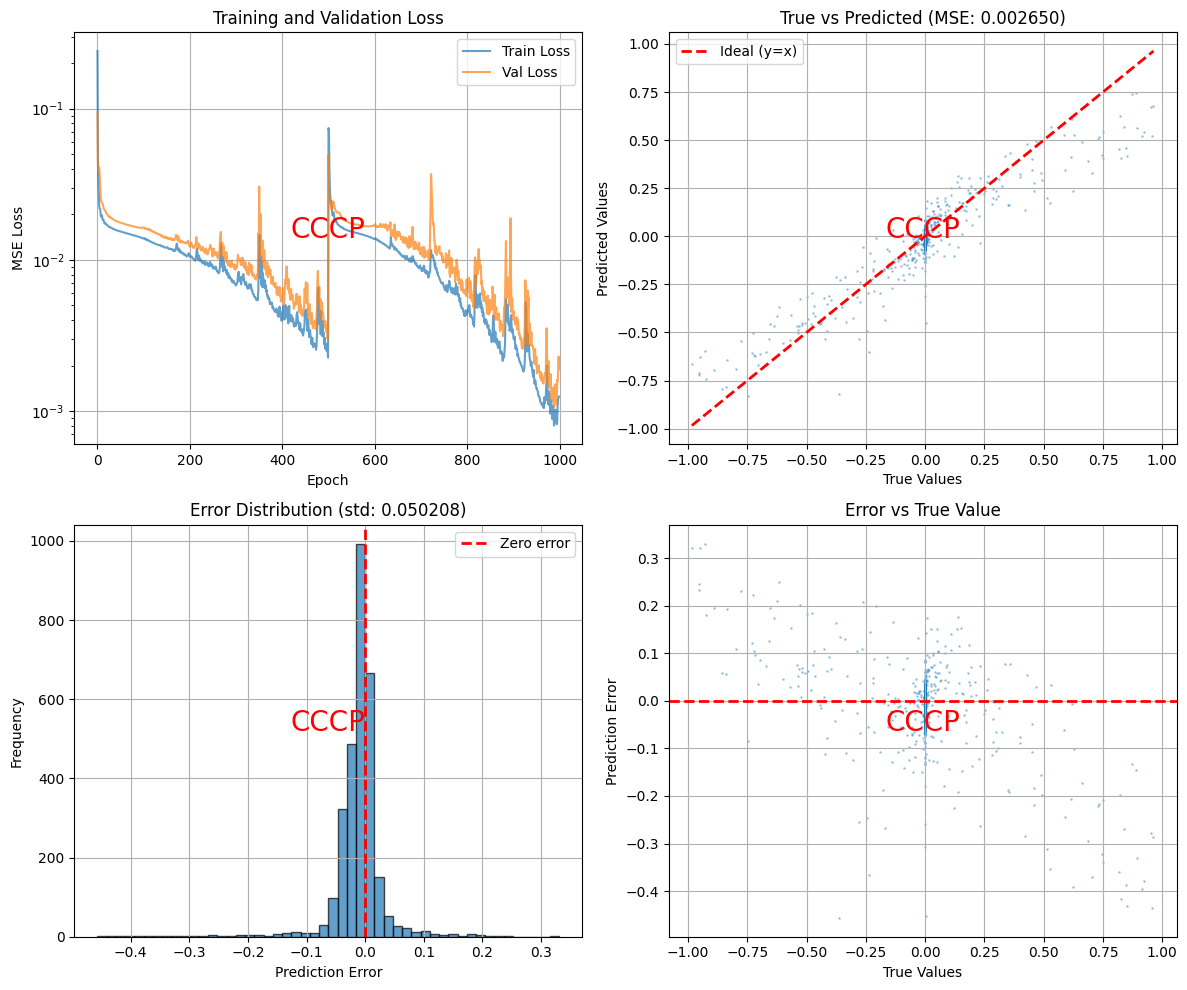

In [132]:
view_result_from_all_visual()

In [136]:
def visual_true_result_3d(fig, Xg, Yg, Z_true):
    ax1 = fig.add_subplot(131, projection='3d')
    surf1 = ax1.plot_surface(Xg, Yg, Z_true, cmap='viridis', alpha=0.8)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title('True Function')
    fig.colorbar(surf1, ax=ax1, shrink=0.5)

In [139]:
def graph_prediction_func_3d(fig, Xg, Yg, Z_pred):
    ax2 = fig.add_subplot(132, projection='3d')
    surf2 = ax2.plot_surface(Xg, Yg, Z_pred, cmap='plasma', alpha=0.8)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    ax2.set_title('Predicted Function')
    fig.colorbar(surf2, ax=ax2, shrink=0.5)

In [140]:
def graph_error_func_3d(fig, Xg, Yg, Z_pred, Z_true):
    ax3 = fig.add_subplot(133, projection='3d')
    error = Z_true - Z_pred
    surf3 = ax3.plot_surface(Xg, Yg, error, cmap='RdYlGn', alpha=0.8)
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    ax3.set_zlabel('Error')
    ax3.set_title(f'Error Map (Max error: {np.abs(error).max():.4f})')
    fig.colorbar(surf3, ax=ax3, shrink=0.5)

In [137]:
grid_x = np.linspace(-10, 10, 100)
grid_y = np.linspace(-10, 10, 100)
Xg, Yg = np.meshgrid(grid_x, grid_y)

X_flat = torch.tensor(np.stack([Xg.ravel(), Yg.ravel()], axis=1), dtype=torch.float32).to(device)
with torch.no_grad():
    Z_pred = model(X_flat).cpu().numpy().reshape(100, 100)

Z_true = np.sin(Xg + 2*Yg) * np.exp(-(2*Xg + Yg)**2)

def view_all_3d():
    fig = plt.figure(figsize=(15, 6))
    visual_true_result_3d(fig, Xg, Yg, Z_true)
    graph_prediction_func_3d(fig, Xg, Yg, Z_pred)
    graph_error_func_3d(fig, Xg, Yg, Z_pred, Z_true)
    plt.tight_layout()
    plt.show()

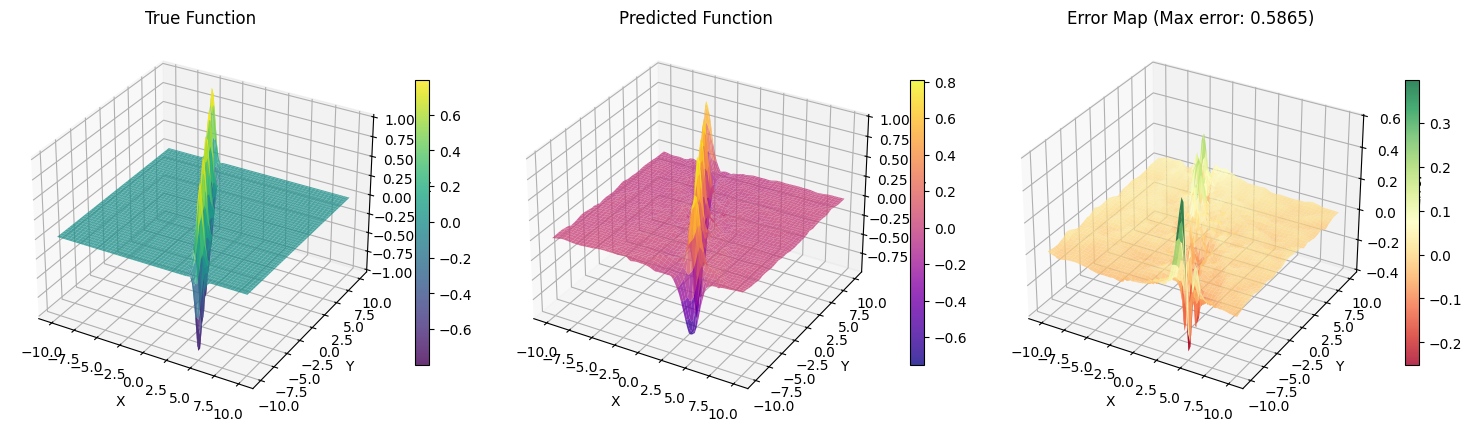

In [141]:
view_all_3d()

In [142]:
def static_report():
    print("\n" + "="*50)
    print("СТАТИСТИЧЕСКИЙ ОТЧЕТ:")
    print("="*50)
    print(f"Размер обучающей выборки: {len(X_train)}")
    print(f"Размер валидационной выборки: {len(X_val)}")
    print(f"Размер тестовой выборки: {len(X_test)}")
    print(f"\nМетрики на тестовой выборке:")
    print(f"  • MSE:  {mse.item():.8f}")
    print(f"  • RMSE: {np.sqrt(mse.item()):.8f}")
    print(f"  • MAE:  {np.abs(errors).mean():.8f}")
    print(f"  • R²:   {1 - mse.item() / np.var(true_np):.8f}")
    print(f"\nДиапазон ошибок:")
    print(f"  • Min error:  {errors.min():.8f}")
    print(f"  • Max error:  {errors.max():.8f}")
    print(f"  • Std error:  {errors.std():.8f}")
    print("="*50)

In [143]:
static_report()


СТАТИСТИЧЕСКИЙ ОТЧЕТ:
Размер обучающей выборки: 14000
Размер валидационной выборки: 3000
Размер тестовой выборки: 3000

Метрики на тестовой выборке:
  • MSE:  0.00265044
  • RMSE: 0.05148241
  • MAE:  0.02613481
  • R²:   0.83578694

Диапазон ошибок:
  • Min error:  -0.45661724
  • Max error:  0.33061957
  • Std error:  0.05020820
